In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve


In [2]:
processed_dir = Path("../data/processed")
figures_dir = Path("../figures")
results_dir = Path("../results")
models_dir = Path("../models")

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


In [3]:
heart_final = pd.read_csv(processed_dir / "heart_final.csv")
train_data = heart_final[heart_final["split"] == "train"].copy()
test_data = heart_final[heart_final["split"] == "test"].copy()

X_train = train_data.drop(columns=["target", "split"])
y_train = train_data["target"]
X_test = test_data.drop(columns=["target", "split"])
y_test = test_data["target"]


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

base_forest = RandomForestClassifier(random_state=42, class_weight="balanced")
grid_search = GridSearchCV(
    estimator=base_forest,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)
grid_search.best_params_, grid_search.best_score_


({'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 300},
 np.float64(0.8329012686155544))

In [5]:
rf_model = grid_search.best_estimator_

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]


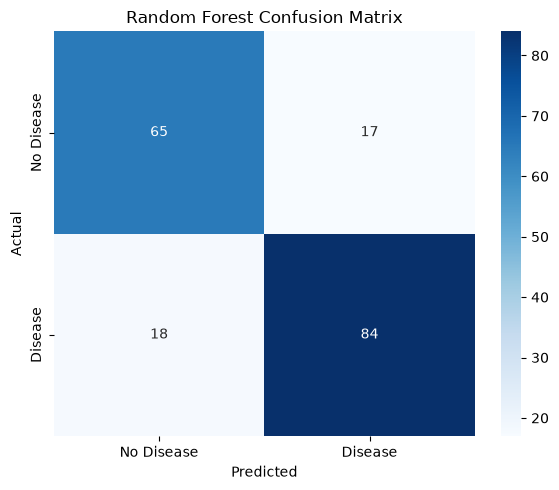

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_forest.png", dpi=300)
plt.show()


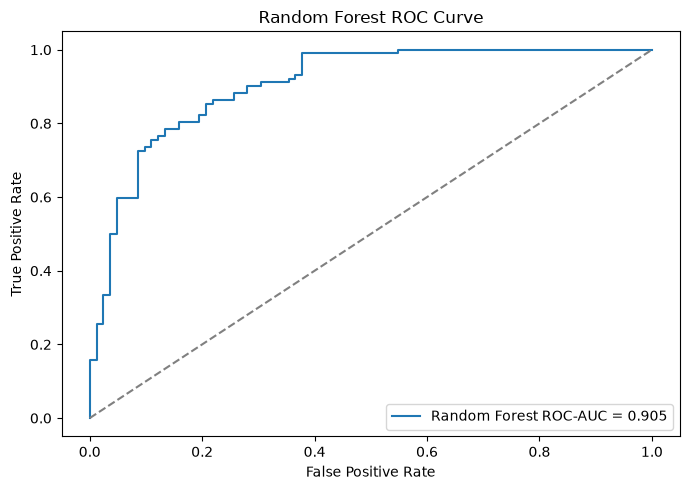

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "roc_curve_forest.png", dpi=300)
plt.show()


In [8]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)
feature_importance.head(15)


,feature,importance
11,cp_asymptomatic,0.116780
4,oldpeak,0.106800
3,thalch,0.097139
2,chol,0.094042
0,age,0.081371
25,exang,0.073396
1,trestbps,0.058988
12,cp_atypical angina,0.054097
6,sex_male,0.034334
22,thal_normal,0.034132


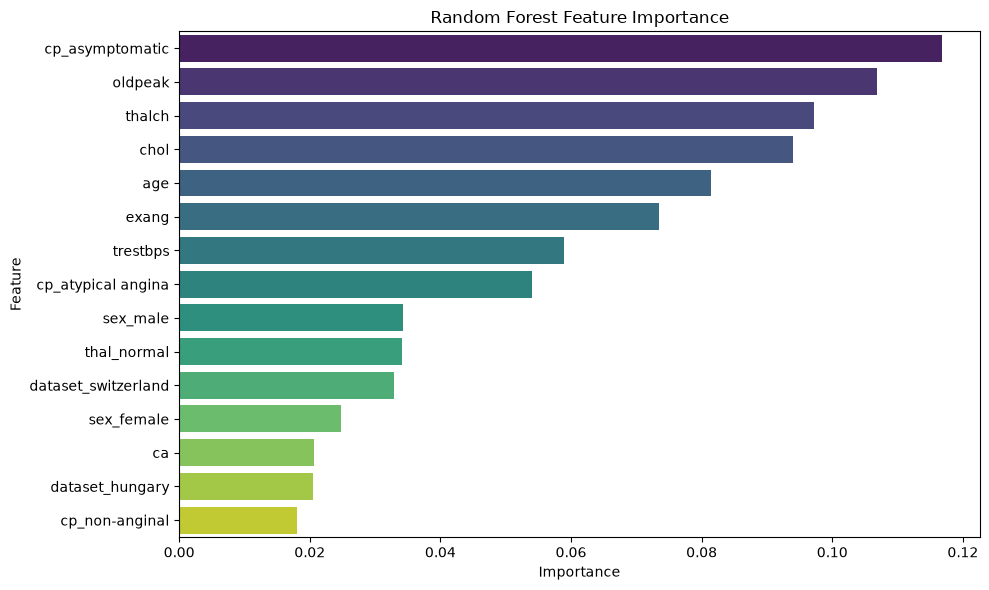

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", hue="feature", legend=False, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "random_forest_feature_importance.png", dpi=300)
plt.savefig(figures_dir / "feature_importance.png", dpi=300)
plt.show()


In [10]:
random_forest_metrics = pd.DataFrame([{
    "model": "Random Forest",
    "best_params": str(grid_search.best_params_),
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": auc_score,
    "cv_mean": grid_search.best_score_,
    "cv_std": grid_search.cv_results_["std_test_score"][grid_search.best_index_]
}])

roc_data = pd.DataFrame({"model": "Random Forest", "fpr": fpr, "tpr": tpr})
random_forest_metrics


,model,best_params,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.809783,0.831683,0.823529,0.827586,0.90483,0.832901,0.036042


In [11]:
random_forest_metrics.to_csv(results_dir / "random_forest_metrics.csv", index=False)
pd.DataFrame(grid_search.cv_results_).to_csv(results_dir / "random_forest_grid_search.csv", index=False)
roc_data.to_csv(results_dir / "random_forest_roc_curve.csv", index=False)
feature_importance.to_csv(results_dir / "random_forest_feature_importance.csv", index=False)
joblib.dump(rf_model, models_dir / "random_forest_model.pkl")


['..\\models\\random_forest_model.pkl']